## Introducción

Como analista de datos, tu objetivo es **evaluar cómo la movilidad urbana se relaciona con la productividad económica en las principales ciudades latinoamericanas**. 
Para ello trabajarás con datos reales de TomTom Traffic Index y OECD Cities, que deberás limpiar, combinar y analizar para identificar en qué ciudades conviene invertir en infraestructura de transporte.

In [1]:
# importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# cargar archivos
traffic = pd.read_csv('/datasets/tomtom_traffic.csv')
eco = pd.read_csv('/datasets/oecd_city_economy.csv')

In [3]:
# mostrar las primeras 5 filas de traffic
traffic.head(5)

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [4]:
# mostrar las primeras 5 filas de eco
eco.head(5)

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"


In [5]:
# Examinar la estructura de traffic
traffic.info()
traffic.head(3)


<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 1004464 entries, 0 to 1004463
,Data columns (total 12 columns):
, #   Column                          Non-Null Count    Dtype  
,---  ------                          --------------    -----  
, 0   Country                         1004464 non-null  object 
, 1   City                            1004464 non-null  object 
, 2   UpdateTimeUTC                   1004464 non-null  object 
, 3   JamsDelay                       1004464 non-null  float64
, 4   TrafficIndexLive                1004464 non-null  float64
, 5   JamsLengthInKms                 1004464 non-null  float64
, 6   JamsCount                       1004464 non-null  float64
, 7   TrafficIndexWeekAgo             1004464 non-null  float64
, 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
, 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
, 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
, 11  MinsDelay                       1004464 non-nul

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232


En la estructura del DF traffic, se observa que:
- Las columnas `UpdateTimeUTC` y `UpdateTimeUTC` son de tipo object
- Estas dos columnas deberian estar en tipo datetime

In [6]:
# Examinar la estructura de eco
eco.info()
eco.head(3)


<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 30 entries, 0 to 29
,Data columns (total 7 columns):
, #   Column           Non-Null Count  Dtype 
,---  ------           --------------  ----- 
, 0   Year             30 non-null     int64 
, 1   City             30 non-null     object
, 2   Country          30 non-null     object
, 3   City GDP/capita  30 non-null     object
, 4   Unemployment %   30 non-null     object
, 5   PM2.5 (μg/m³)    30 non-null     object
, 6   Population (M)   30 non-null     object
,dtypes: int64(1), object(6)
,memory usage: 1.8+ KB


,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"


En la estructura del DF eco, se observa que:
- Las columnas `City GDP/capita`, `Unemployment %`, tienne Dtype object
- Deberian tener Dtype int64

In [7]:
# Estandarizar los nombres de las columnas de traffic Country → country UpdateTimeUTC → update_time_utc
traffic.columns = ["country","city","update_time_utc","jams_delay","traffic_index_live","jams_length_in_kms","jams_count","traffic_index_week_ago","update_time_utc_week_ago",
                   "travel_time_live_per_10kms_mins","travel_time_historic_per_10kms_mins","mins_delay"]

# verificar cambios
traffic.columns

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_in_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10kms_mins',
       'travel_time_historic_per_10kms_mins', 'mins_delay'],
      dtype='object')

In [8]:
# Estandarizar los nombres de las columnas de eco
eco.columns = ['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct','pm25', 'population_m']

# verificar cambios
eco.columns

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct',
       'pm25', 'population_m'],
      dtype='object')

In [9]:
# Convertir las columnas de traffic a tipo fecha con pd.to_datetime()
traffic['update_time_utc'] = pd.to_datetime(traffic['update_time_utc'], errors='coerce')
traffic['update_time_utc_week_ago'] = pd.to_datetime(traffic['update_time_utc_week_ago'], errors='coerce')

# verificar el cambio
traffic.info()

<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 1004464 entries, 0 to 1004463
,Data columns (total 12 columns):
, #   Column                               Non-Null Count    Dtype         
,---  ------                               --------------    -----         
, 0   country                              1004464 non-null  object        
, 1   city                                 1004464 non-null  object        
, 2   update_time_utc                      1004464 non-null  datetime64[ns]
, 3   jams_delay                           1004464 non-null  float64       
, 4   traffic_index_live                   1004464 non-null  float64       
, 5   jams_length_in_kms                   1004464 non-null  float64       
, 6   jams_count                           1004464 non-null  float64       
, 7   traffic_index_week_ago               1004464 non-null  float64       
, 8   update_time_utc_week_ago             1004464 non-null  datetime64[ns]
, 9   travel_time_live_per_10kms_mins      100446

In [10]:
# Limpia separadores y convierte columnas numéricas en eco
eco['city_gdp_capita'] = (eco['city_gdp_capita'].astype(str).str.replace('.','').str.replace(',', '.').astype(float))
eco['unemployment_pct'] = (eco['unemployment_pct'].astype(str).str.replace('%','').str.replace(',', '.').astype(float))
eco['population_m'] = (eco['population_m'].astype(str).str.replace(',', '.').astype(float))

# Se calcula la población total en unidades absolutas (Multiplica * 1000000)
eco['population'] = eco['population_m']*1000000

# verificar el cambio
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 30 entries, 0 to 29
,Data columns (total 8 columns):
, #   Column            Non-Null Count  Dtype  
,---  ------            --------------  -----  
, 0   year              30 non-null     int64  
, 1   city              30 non-null     object 
, 2   country           30 non-null     object 
, 3   city_gdp_capita   30 non-null     float64
, 4   unemployment_pct  30 non-null     float64
, 5   pm25              30 non-null     object 
, 6   population_m      30 non-null     float64
, 7   population        30 non-null     float64
,dtypes: float64(4), int64(1), object(3)
,memory usage: 2.0+ KB


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
0,2023,buenos-aires,Argentina,15782.0,6.2,"15,2",15.3,15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1,"29,50",22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,"19,10",13.6,13600000.0


In [11]:
#Crear una nueva columna llamada 'year' para filtrar la informacion y trabajar con el periodo solicitado
# Extraer el año de las fechas en update_time_utc
traffic['year'] = pd.to_datetime(traffic['update_time_utc']).dt.year

# Verificar cambio
traffic.head(3)

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232,2025


In [12]:
# Filtra los registros del año 2024
#Creamos dos nuevos DataFrames para evitar modificar el dataset original
traffic_2024 = traffic[traffic['year'] == 2024].copy()
eco_2024 = eco[eco['year'] == 2024].copy()

# Revisar dataframes nuevos
display(traffic_2024.head())
display(eco_2024.head())


,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30.000,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30.000,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30.000,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30.000,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30.000,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00.000,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00.000,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
15,2024,buenos-aires,Argentina,18117.0,7.2,"14,50",15.4,15400000.0
16,2024,sao-paulo,Brazil,14703.0,8.5,"28,00",22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,13349.0,9.2,"18,40",13.7,13700000.0
18,2024,brasilia,Brazil,16251.0,7.8,"12,80",4.8,4800000.0
19,2024,salvador,Brazil,8899.0,12.4,"15,20",3.9,3900000.0


In [13]:
# Agrupar los datos por ciudad, país y año
# Calcular el promedio solo de las métricas de tráfico más relevantes
# Reinicia el índice para mantener las columnas de la agrupación como variables (no índices).

traffic_city_year_2024 =  traffic_2024.groupby(["city","country","year"])\
                                        .agg({"jams_delay":"mean", "traffic_index_live":"mean", "jams_length_in_kms":"mean", "jams_count":"mean",
                                        "mins_delay":"mean","travel_time_live_per_10kms_mins":"mean", "travel_time_historic_per_10kms_mins":"mean"})\
                                        .reset_index()


# Mostrar resultado
traffic_city_year_2024.head()

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


In [14]:
#Ahora que ya tenemos los promedios anuales por ciudad, podemos tomar un momento para observarlos.
#Podemos observar que ciudad tiene el mayor tiempo promedio de tráfico
traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)



,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
...,...,...,...,...,...,...,...,...,...,...
111,dunedin,NZL,2024,4.651175,15.430809,0.712315,1.591384,0.633294,16.226009,15.592715
363,uppsala,SWE,2024,4.194486,13.939168,0.656368,1.349672,0.501802,15.746717,15.244916
123,fujairah,ARE,2024,4.025959,10.907719,0.731910,1.373006,0.194951,11.662590,11.467639
12,almere,NLD,2024,3.633523,6.290478,0.506362,1.064063,-0.017544,9.467150,9.484694


La ciudad con el mayor tiempo promedio de tráfico es mexico-city

In [15]:
# Seleccionar columnas clave de tráfico y economía
left_cols = ['city','country','year','jams_delay','traffic_index_live',
             'jams_length_in_kms','jams_count','mins_delay',
             'travel_time_live_per_10kms_mins','travel_time_historic_per_10kms_mins']

right_cols = ['city','year','city_gdp_capita','unemployment_pct','pm25','population']

# Usar .copy() para crear los dos nuevos datasets reducidos y evitar modificar el original
traffic_2024_small = traffic_city_year_2024[left_cols].copy()
eco_2024_small = eco_2024[right_cols].copy()

# Unir datasets y definir como claves de unión a 'city' y 'year'
# Mantenemos solo las ciudades y años presentes con 'inner'
merged = pd.merge(traffic_2024_small, eco_2024_small, on=["city","year"], how="inner" )

# Mostrar las primeras 5 filas
merged.head(5)

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,city_gdp_capita,unemployment_pct,pm25,population
0,belo-horizonte,BRA,2024,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,11124.0,9.5,"16,80",6100000.0
1,bogota,COL,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,11442.0,10.0,"17,60",11300000.0
2,brasilia,BRA,2024,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,16251.0,7.8,"12,80",4800000.0
3,buenos-aires,ARG,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,18117.0,7.2,"14,50",15400000.0
4,curitiba,BRA,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,12381.0,8.2,"13,50",3700000.0


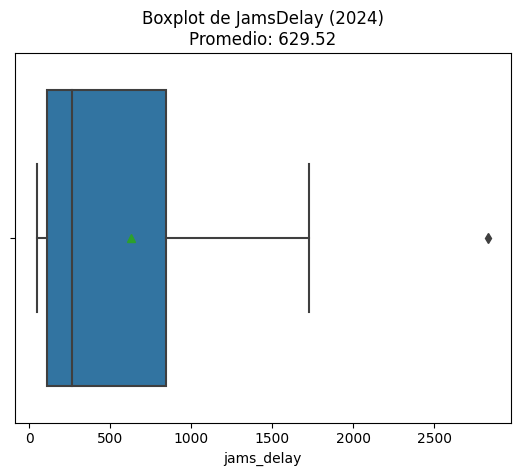

In [16]:
# Crear boxplot para observar el comportamiento de los minutos de congestion JamsDelay y observar los las respectivas media, mediana y detectar valores atípicos.

sns.boxplot(data=merged, x='jams_delay', showmeans=True)
# obtener promedio para mostrarlo en título
mean_value = merged['jams_delay'].mean()
plt.title(f'Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}')
plt.show()





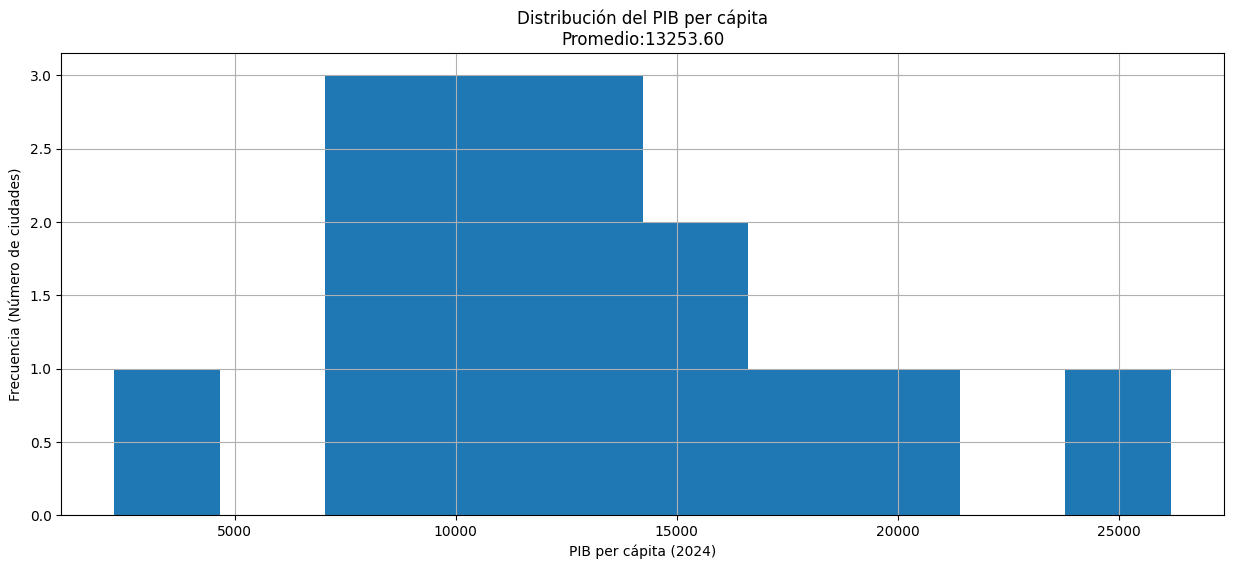

In [17]:
# Crear histograma para ver la distribución de la economía (city_gdp_capita) y el valor promedio del PIB per cápita.
merged['city_gdp_capita'].hist(bins=10, figsize=(15,6))
mean_value2 = merged['city_gdp_capita'].mean()
plt.title(f'Distribución del PIB per cápita\nPromedio:{mean_value2:.2f}')
plt.xlabel('PIB per cápita (2024)')
plt.ylabel('Frecuencia (Número de ciudades)')
plt.show()


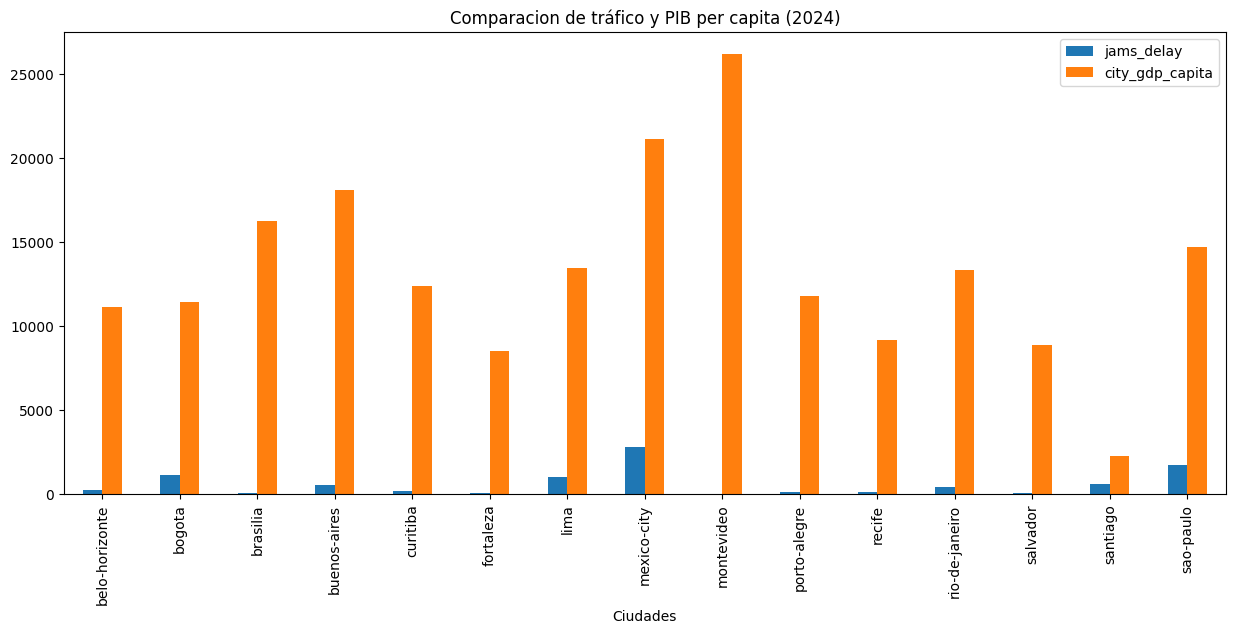

In [18]:
# Gráfico de barras para comparar jams_delay y city_gdp_capita por ciudad
merged.plot(x='city', y=['jams_delay', 'city_gdp_capita'],kind='bar',figsize=(15,6))
plt.xticks(rotation=90)
plt.title('Comparacion de tráfico y PIB per capita (2024)')
plt.xlabel('Ciudades')
plt.show()


In [19]:
# Exporta el dataset final como CSV
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)

# 🧾 Resumen ejecutivo


**Contexto & objetivo:**  

- La movilidad urbana tiene una relación positiva pero débil con la productividad económica medida en PIB per cápita. Ciudades con mayor congestión vehicular no necesariamente tienen menor productividad económica. La relación entre estos dos es indirecta, porque se encuentran ciudades que llegan a lograr ambos objetivos (bajo tráfico + alto PIB), y otras que sufren ambos problemas (alto tráfico + bajo PIB).
- Las variables clave del análisis combinan indicadores de movilidad (jams delay) y de productividad económica (PIB per cápita). Estos factores permiten identificar de manera integral las áreas donde una inversión en infraestructura de transporte podría mejorar tanto la eficiencia de la movilidad como la productividad económica de las ciudades.

**Cobertura de datos:**  

El análisis incluye:

- Período: 2024

- Número de ciudades: 15 ciudades latinoamericanas

- Número de países: 7 (Argentina, Brasil, Chile, Colombia, México, Perú, Uruguay)


**Metodología (alto nivel):**  

- Se realizó un proceso de limpieza y estandarización a formato decimal con puntos a los datos numericos , la conversión de textos a valores numéricos en variables como PIB, desempleo y población, y el tratamiento de fechas mediante su transformación a tipo datetime con extracción del año 2024.
- Se integraron datos de movilidad y economía. Los registros de tráfico se agregaron al promedio anual por ciudad, y mediante un INNER JOIN en las claves city y year se unieron ambos conjuntos, conservando únicamente las ciudades presentes en los dos.
- Se aplicaron diferentes técnicas de visualización para analizar los datos: un boxplot permitió observar la distribución de los retrasos de tráfico y detectar posibles outliers; un histograma mostró cómo se concentra el PIB per cápita en las ciudades; y los gráficos de barras compararon los patrones de movilidad y economía entre ellas.

**Hallazgos iniciales:**  
- Existe una relación positiva débil entre congestión vehicular y PIB per cápita. Esto significa que: Ciudades con mayor congestión NO necesariamente tienen menor productividad económica, deben de haber algunos factores además del tráfico que determinan la productividad económica. La relación entre congeestion vehicular y PIB per capita es compleja y depende de muchos más factores
- Un outlier positivo se encuentra en Montevideo, se enmcuentra una baja congestion (50.20 min) y un alto PIB (2,618M). Esto indica que hay un buen desarrollo económico con bajo tráfico. Montevideo es un buen modelo para replicar en las otras ciudades.
- Un outlier negativo se encuentra en Santiago, hay una congestión moderada (629.86 min), pero el PIB es el más bajo de la región (228M). Puede que hayan problemas económicos mas haya de la congestion, realmente se necesita un análisis mas profundo, pero la infraestructura de transporte podría ser parte de la solución.



